In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/aleksei/projects/code-of-kutulu-client')

In [3]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def check_policy(Q):
    result_list = []
    for _dist in range(5):
        for _dir in range(4):
            result = np.argmax(Q.get(((_dir,), _dist, None, None), [0])) == _dir
            result_list.append(result)
    return np.mean(result_list)

In [5]:
from src.envs.kutulu_world import KutuluWorldEnv, DEFAULT_KUTULU_ACTIONS
from src.envs.distance import find_path
from src.envs.kutulu_player import KutuluPlayer
from src.envs.strategy import RandomStrategy, GreedyStrategy, LazyGreedyStrategy

In [6]:
env = KutuluWorldEnv(
    server_host='localhost:8080',
    maze_name="Hypersonic",
    league_level=1,
    players_count=4,
)

In [7]:
player = KutuluPlayer(env)

In [8]:
pi = LazyGreedyStrategy()
eps=0.05
alpha=0.1
gamma=0.99
num_experiments=10000
can_wait=True
verbose=False
reward_list = []
quality_list = []

In [9]:
Q = pi.Q
random_player_ids = set([1, 2, 3])

In [10]:
for i in tqdm(range(num_experiments)):
    observation, info = env.reset()
    rollout_rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
        
        state_actions = {}
        for env_player in env.active_players():
            player_id = env_player['id']
            if player_id in random_player_ids:
                continue
            state = player.get_state(player_id, max_explorer_dist=5, max_wanderer_dist=5)
            player_mask = ~np.array(player.env.get_valid_action_mask()[player_id])
            At = pi.getActionEpsGreedyMasked(state, len(DEFAULT_KUTULU_ACTIONS), eps, player_mask)
            action[player_id] = At
            state_actions[player_id] = (state, At)

        entities, rewards, game_over, info = env.step(action)
        rollout_rewards.append(rewards)

        for player_id, reward in enumerate(rewards):
            if player_id in random_player_ids:
                continue
            if reward is None:
                continue
            if player_id not in state_actions:
                continue
            state, At = state_actions[player_id]
            
            if game_over:
                Q[state][At] += alpha * (reward - Q[state][At])
            else:
                Q[state][At] += alpha * (
                    reward + gamma * Q[state].max() - Q[state][At]
                )
        
        if verbose:
            viz_map(env.map, entities['entities'])

    reward_list.append(rollout_rewards)
    quality_list.append(check_policy(pi.Q))
    if i % 10 == 0:
        total_reward_list = np.array([np.nansum(np.array(rewards, dtype=float), axis=0) for rewards in reward_list])
        mean_rewards = np.mean(total_reward_list, axis=0)
        print(f"i={i}\tquality={quality_list[-1]:.2f}\tmean_reward=[{', '.join(f'{x:.2f}' for x in mean_rewards)}]")

  0%|          | 1/10000 [00:00<1:02:35,  2.66it/s]

i=0	quality=0.25	mean_reward=[-202.00, -186.00, 843.00, -178.00]


  0%|          | 11/10000 [00:03<53:25,  3.12it/s] 

i=10	quality=0.30	mean_reward=[-97.45, 87.09, 303.55, 21.73]


  0%|          | 21/10000 [00:07<1:03:39,  2.61it/s]

...

i=2240	quality=0.45	mean_reward=[544.62, -136.64, 31.71, -64.61]


 23%|██▎       | 2251/10000 [17:38<1:02:16,  2.07it/s]

i=2250	quality=0.40	mean_reward=[544.22, -136.89, 31.81, -64.15]


 23%|██▎       | 2256/10000 [17:41<1:00:42,  2.13it/s]


KeyboardInterrupt: 

In [11]:
total_reward_list = np.array([np.nansum(np.array(rewards, dtype=float), axis=0) for rewards in reward_list])

In [12]:
winner_list = np.argmax(total_reward_list, 1)

In [13]:
Counter(winner_list)

Counter({2: 393, 0: 1519, 1: 133, 3: 211})

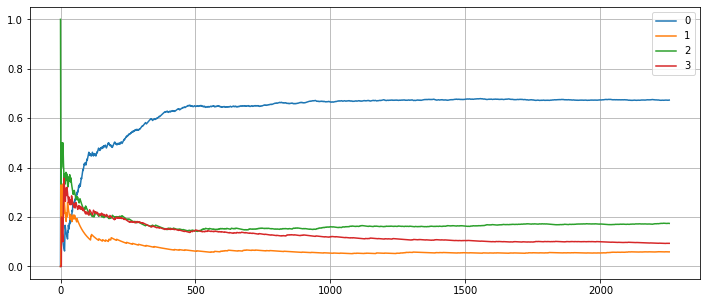

In [14]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [15]:
num_experiments=100
can_wait=True
verbose=False
reward_list = []

In [16]:
Q = pi.Q
random_player_ids = set([0, 1, 2])

In [18]:
for _ in tqdm(range(num_experiments)):
    observation, info = env.reset()
    rollout_rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
        
        state_actions = {}
        for env_player in env.active_players():
            player_id = env_player['id']
            if player_id in random_player_ids:
                continue
            state = player.get_state(player_id, max_explorer_dist=5, max_wanderer_dist=5)
            player_mask = ~np.array(player.env.get_valid_action_mask()[player_id])
            At = pi.getActionGreedyMasked(state, len(DEFAULT_KUTULU_ACTIONS), player_mask)
            action[player_id] = At
            state_actions[player_id] = (state, At)

        entities, rewards, game_over, info = env.step(action)
        rollout_rewards.append(rewards)
        
        if verbose:
            viz_map(env.map, entities['entities'])

    reward_list.append(rollout_rewards)

100%|██████████| 100/100 [00:39<00:00,  2.54it/s]


In [19]:
total_reward_list = np.array([np.nansum(np.array(rewards, dtype=float), axis=0) for rewards in reward_list])

In [20]:
winner_list = np.argmax(total_reward_list, 1)

In [21]:
Counter(winner_list)

Counter({0: 15, 2: 25, 3: 39, 1: 21})

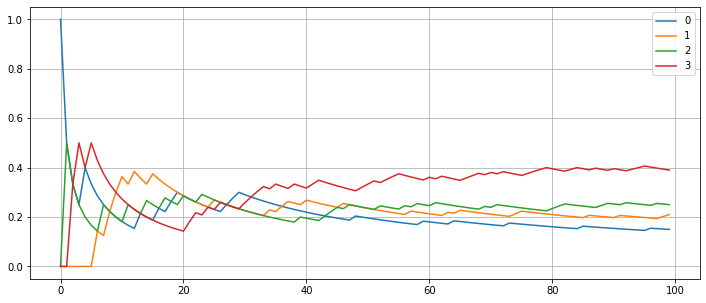

In [22]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [24]:
import pickle as pkl
import zlib
import base64

In [25]:
len([k for k in pi.Q.keys()])

2187

In [28]:
new_keys = [k for k in pi.Q.keys() if ((k[1] or 0) < 8) and ((k[3] or 0) < 6)]

In [29]:
len(new_keys)

2187

In [47]:
data1 = pkl.dumps(np.array(list(pi.Q[k] for k in new_keys), dtype='float16'))
data2 = pkl.dumps(list(new_keys))

In [54]:
from datetime import datetime

In [57]:
str(datetime.now())

'2025-04-30 20:46:10.428340'

In [59]:
import os

In [60]:
model_dir = f"../output/{datetime.now()}"

In [70]:
date, time = model_dir.split()

In [73]:
os.mkdir(date, )
os.mkdir(f"{date}/{time}")

In [74]:
!ls ../output/2025-04-30/20\:47\:29.344655

In [77]:
with open(f"{date}/{time}/data1.pkl", "wb") as f:
    f.write(data1)

In [80]:
with open(f"{date}/{time}/data2.pkl", "wb") as f:
    f.write(data2)

In [81]:
with open(f"{date}/{time}/data1.pkl", "rb") as f:
    data1 = f.read()

In [82]:
with open(f"{date}/{time}/data2.pkl", "rb") as f:
    data2 = f.read()

In [86]:
Q = {k: v for k,v in zip(pkl.loads(data2), pkl.loads(data1))}

{((2,),
  2,
  None,
  None): array([-0.6826, -0.7305, -0.2825, -0.6045, -0.762 ], dtype=float16),
 ((0,),
  2,
  None,
  None): array([-0.01726, -0.3826 , -0.3296 , -0.507  , -0.4194 ], dtype=float16),
 ((2,),
  4,
  None,
  None): array([ 0.04373, -0.8413 ,  0.0705 ,  0.481  ,  0.01747], dtype=float16),
 ((0, 1),
  4,
  None,
  None): array([-1.041 ,  0.1558, -1.256 , -1.188 , -1.232 ], dtype=float16),
 ((1, 2),
  4,
  None,
  None): array([-1.125, -1.21 , -1.063, -1.614, -1.104], dtype=float16),
 ((0,),
  4,
  None,
  None): array([-1.152  , -0.08466, -0.958  , -0.2421 , -1.926  ], dtype=float16),
 ((1, 2),
  3,
  None,
  None): array([-1.674 , -1.205 , -0.3792,  0.644 ,  0.4795], dtype=float16),
 ((0,),
  3,
  None,
  None): array([-2.082, -1.979, -1.912, -1.894, -1.877], dtype=float16),
 ((1, 2),
  2,
  None,
  None): array([-0.1918 , -0.01144, -0.01683, -0.5874 , -0.2079 ], dtype=float16),
 ((0, 3),
  2,
  None,
  None): array([ 0.878  , -0.02435,  0.7197 ,  0.792  ,  0.8755 ], d

In [53]:
# base64.b64encode(zlib.compress(data2, level=9))

In [49]:
len(base64.b64encode(zlib.compress(data1, level=9)))

27456

In [33]:
len(base64.b64encode(zlib.compress(data2, level=9)))

27360